In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

In [ ]:
def hough_line_detection(edge):
    care = edge == 255 # 边缘所在点的掩膜
    positions = np.where(care) # 返回元组，第一个矩阵储存行即y坐标， 第二个矩阵储存x坐标
    # 把x坐标放前面 # [nums, x, y]格式
    positions_np = np.concatenate([positions[1][..., np.newaxis], positions[0][..., np.newaxis]], axis=1) 
    
    # 霍夫变换
    thetas=np.deg2rad(np.arange(0,180))
    cos_t = np.cos(thetas)[...,np.newaxis]
    sin_t = np.sin(thetas)[...,np.newaxis] # [180, 1]
    rho_np = positions_np[:,0]*cos_t + positions_np[:,1]*sin_t # [180, nums], nums个点对应180个角度的rho
    rho_np_int = np.ceil(rho_np) # 向上取整，仍为浮点数
    
    voteDict = {} # 投票字典
    angle_keys = []
    for _i, _ang in enumerate(thetas):
        _rho_1 = rho_np_int[_i] # 取一个角度下的所有rho
        _rho_vote = Counter(_rho_1) # 用Counter完成对相同rho的计数，并以字典的形式组织
        k = str(_ang)
        voteDict[k] = _rho_vote # 更新该角度的投票字典
        angle_keys.append(k)
    return voteDict,angle_keys, rho_np_int

In [ ]:
def back_process(voteDict,angle_keys, offset=30, lines_num=6, most=50, angle=0):
    
    line_dict = {}
    oneAngRhos = voteDict[angle_keys[angle]]
    if len(oneAngRhos.keys()) < most:
        most = len(oneAngRhos.keys())
    oneAngRhos = voteDict[angle_keys[angle]].most_common(most) # 已经是降序排列了
    line_dict[str(oneAngRhos[0][0])] = [0]

    for i in range(1, len(oneAngRhos)):
        _vote_rho = str(oneAngRhos[i][0])
        _keys = line_dict.keys()
        _keys = list(_keys)
        # print(_keys)
        
        _flag1 = False
        for _key in _keys:
            _diff = float(_key) - float(_vote_rho)
            if abs(_diff) <= offset:
                line_dict[_key].append(_diff)
                _flag1 = True
                break
        if _flag1 == True:
            continue
        else:
            if len(_keys)<lines_num:
                line_dict[_vote_rho] = [0]
    return line_dict

In [82]:
img = cv2.imread(r'C:\Users\hp\Desktop\4_test\testv1\8.jpg')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_canny = cv2.Canny(img_gray, 200, 300, apertureSize=3)
_c = img_canny.copy()

In [83]:
voteDict,angle_keys, rho_np_int = hough_line_detection(_c)

In [ ]:
ang = 0
line0 = back_process(voteDict, angle_keys, offset=30, lines_num=9,most=100, angle=ang)
print(line0)

In [84]:
_votes = []
for _it in angle_keys:
    _oarho = voteDict[_it].most_common(1)
    _votes.append(_oarho[0][1])
max_vote = np.array(_votes)
max_vote = np.argsort(-max_vote)
_care = max_vote[0:4]
index_list = []
index_list.append(_care[0])
for _it in _care:
    if abs(_it - index_list[0]) >= 88 and abs(_it - index_list[0]) <= 92:
        index_list.append(_it)
        break

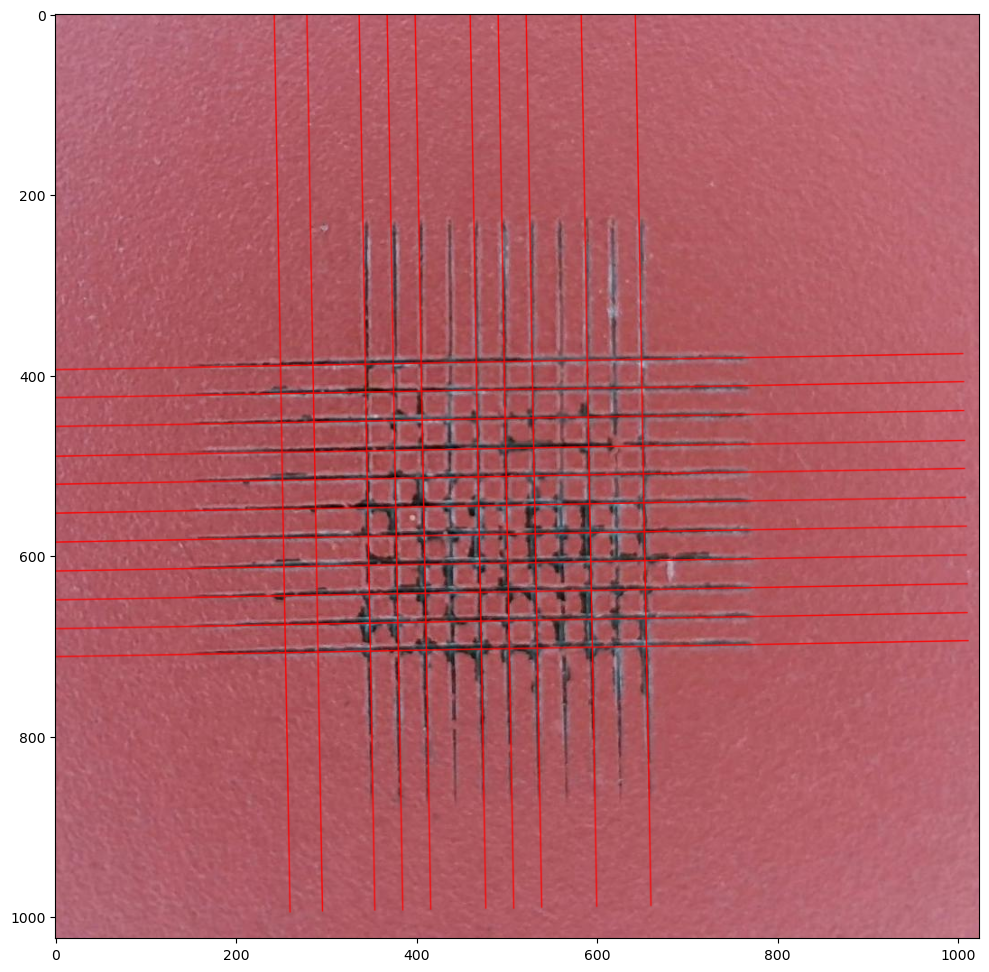

In [86]:
_img = img.copy()
for ang in index_list:
    line0 = back_process(voteDict, angle_keys, offset=30, lines_num=11,most=100, angle=ang)
    for _item in list(line0.keys()):
        _rho = float(_item)
        _theta = float(angle_keys[ang])
        a = np.math.cos(_theta)
        b = np.math.sin(_theta)
        x0 = a*_rho
        y0 = b*_rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        
        cv2.line(_img, pt1, pt2, (0,0,255), 1, cv2.LINE_AA)
plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(_img, cv2.COLOR_BGR2RGB))

In [ ]:
_img = img.copy()
for _item in list(line0.keys()):
    _rho = float(_item)
    _theta = float(angle_keys[ang])
    a = np.math.cos(_theta)
    b = np.math.sin(_theta)
    x0 = a*_rho
    y0 = b*_rho
    pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
    pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
    
    cv2.line(_img, pt1, pt2, (0,0,255), 1, cv2.LINE_AA)
plt.figure(figsize=(12,12))
plt.imshow(cv2.cvtColor(_img, cv2.COLOR_BGR2RGB))